# Sentiment Classification Baseline Comparison Demo

This notebook demonstrates a comparison of two simple baselines for binary sentiment classification:
1. **Multinomial Naive Bayes**
2. **Logistic Regression**

Both models use TF-IDF features extracted from text. The demo uses a curated subset of the **SST-2** dataset (Stanford Sentiment Treebank) containing movie review sentences with binary sentiment labels (0=negative, 1=positive).

This is a minimal demo version of the full artifact which contains 3 datasets (SST-2, IMDB, Twitter Financial News) totaling 95,714 examples. The full artifact is available at: https://github.com/ai-inventor-papers/ai-invention-2f324c-disagreement-asymmetry-oracle

In [1]:
# Install dependencies — follows aii-colab pattern
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *a])

# Packages NOT pre-installed on Colab (always install everywhere)
_pip("loguru==0.7.3")

# Core packages (pre-installed on Colab, install locally to match Colab env)
if "google.colab" not in sys.modules:
    _pip("numpy==2.0.2", "scikit-learn==1.6.1", "scipy==1.16.3", "matplotlib==3.10.0", "seaborn==0.13.2")


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# Imports — copied from original baseline.py
from loguru import logger
from pathlib import Path
import sys
import json
import time
import hashlib

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# NumPy 2.0 compatibility shim
if not hasattr(np, "alltrue"): np.alltrue = np.all
if not hasattr(np, "sometrue"): np.sometrue = np.any
if not hasattr(np, "product"): np.product = np.prod

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
# Data loading helper — uses GitHub URL with local fallback
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-2f324c-disagreement-asymmetry-oracle/main/round-1/dataset-1/demo/mini_demo_data.json"

import urllib.request

def load_data():
    """Load mini demo data from GitHub URL with local fallback."""
    try:
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    local = Path("mini_demo_data.json")
    if local.exists():
        return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json from GitHub or local")

In [4]:
# Load the data
data = load_data()
print(f"Loaded {data["metadata"]["num_datasets"]} dataset(s) with {data["metadata"]["total_examples"]} total examples")
for ds in data["datasets"]:
    print(f"  {ds["dataset"]}: {len(ds["examples"])} examples")
    labels = [ex["output"] for ex in ds["examples"]]
    print(f"    Label distribution: {np.bincount([int(l) for l in labels])}")

Loaded 1 dataset(s) with 12 total examples
  stanfordnlp_sst2: 12 examples
    Label distribution: [6 6]


In [5]:
# Config — ALL tunable parameters at minimum values for demo
# These are the absolute minimum values that produce any output

# Data parameters
TEST_SIZE = 0.25           # Minimum test split (3 examples for 12 total)
RANDOM_STATE = 42          # Fixed seed for reproducibility

# TF-IDF parameters
MAX_FEATURES = 100         # Minimum vocabulary size
NGRAM_RANGE = (1, 1)       # Unigrams only (minimal)
MIN_DF = 1                 # Minimum document frequency

# Model parameters
NB_ALPHA = 0.1             # Naive Bayes smoothing
LR_MAX_ITER = 100          # Minimum iterations for convergence
LR_C = 1.0                 # Regularization strength
LR_SOLVER = "lbfgs"        # Solver

# Other
TARGET_NAMES = ["Negative", "Positive"]  # For classification reports

## Data Preparation

Extract texts and labels from the loaded data, filter and prepare for train/test split.

In [6]:
# Extract data from the loaded dataset (SST-2)
dataset = data["datasets"][0]  # stanfordnlp_sst2
examples = dataset["examples"]

texts_all = [ex["input"] for ex in examples]
labels_all = [int(ex["output"]) for ex in examples]

logger.info(f"Total samples: {len(texts_all)}, label dist: {np.bincount(labels_all)}")

08:20:14|INFO   |Total samples: 12, label dist: [6 6]


## Train/Test Split

Split the data with stratification to maintain label distribution.

In [7]:
# Split train/test with stratification
texts_train, texts_test, labels_train, labels_test = train_test_split(
    texts_all, labels_all,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=labels_all
)
logger.info(f"Train: {len(texts_train)} samples, Test: {len(texts_test)} samples")
logger.info(f"Train label dist: {np.bincount(labels_train)}")
logger.info(f"Test label dist: {np.bincount(labels_test)}")

08:20:14|INFO   |Train: 9 samples, Test: 3 samples


08:20:14|INFO   |Train label dist: [4 5]


08:20:14|INFO   |Test label dist: [2 1]


## TF-IDF Vectorization

Convert text to TF-IDF feature vectors using the configured parameters.

In [8]:
# Build TF-IDF vectors
logger.info("Building TF-IDF vectors...")
tfidf = TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE, min_df=MIN_DF)
X_train = tfidf.fit_transform(texts_train)
X_test = tfidf.transform(texts_test)
logger.info(f"TF-IDF matrix: {X_train.shape}")
logger.info(f"Vocabulary size: {len(tfidf.vocabulary_)}")

08:20:14|INFO   |Building TF-IDF vectors...


08:20:14|INFO   |TF-IDF matrix: (9, 54)


08:20:14|INFO   |Vocabulary size: 54


## Baseline 1: Multinomial Naive Bayes

Train and evaluate a Multinomial Naive Bayes classifier with Laplace smoothing.

In [9]:
# --- Baseline 1: Naive Bayes ---
logger.info("Training Naive Bayes...")
t0 = time.time()
nb = MultinomialNB(alpha=NB_ALPHA)
nb.fit(X_train, labels_train)
nb_pred = nb.predict(X_test)
nb_time = time.time() - t0

nb_acc = accuracy_score(labels_test, nb_pred)
nb_f1 = f1_score(labels_test, nb_pred, average="weighted")
logger.info(f"Naive Bayes — Accuracy: {nb_acc:.4f}, F1: {nb_f1:.4f}, Time: {nb_time:.2f}s")
print(classification_report(labels_test, nb_pred, target_names=TARGET_NAMES))

08:20:14|INFO   |Training Naive Bayes...


08:20:14|INFO   |Naive Bayes — Accuracy: 0.3333, F1: 0.1667, Time: 0.01s


              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         2
    Positive       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



/ai-inventor/aii_data/runs/run_q27XJGeAT3TE/4_gen_paper_repo/_3_gen_demo_art/notebook_workspaces/iter_1/art_N1k1rKbMgdgf/.nb_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/ai-inventor/aii_data/runs/run_q27XJGeAT3TE/4_gen_paper_repo/_3_gen_demo_art/notebook_workspaces/iter_1/art_N1k1rKbMgdgf/.nb_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/ai-inventor/aii_data/runs/run_q27XJGeAT3TE/4_gen_paper_repo/_3_gen_demo_art/notebook_workspaces/iter_1/art_N1k1rKbMgdgf/.nb_env/l

## Baseline 2: Logistic Regression

Train and evaluate a Logistic Regression classifier.

In [10]:
# --- Baseline 2: Logistic Regression ---
logger.info("Training Logistic Regression...")
t0 = time.time()
lr = LogisticRegression(max_iter=LR_MAX_ITER, C=LR_C, solver=LR_SOLVER, random_state=RANDOM_STATE)
lr.fit(X_train, labels_train)
lr_pred = lr.predict(X_test)
lr_time = time.time() - t0

lr_acc = accuracy_score(labels_test, lr_pred)
lr_f1 = f1_score(labels_test, lr_pred, average="weighted")
logger.info(f"Logistic Regression — Accuracy: {lr_acc:.4f}, F1: {lr_f1:.4f}, Time: {lr_time:.2f}s")
print(classification_report(labels_test, lr_pred, target_names=TARGET_NAMES))

08:20:14|INFO   |Training Logistic Regression...


08:20:14|INFO   |Logistic Regression — Accuracy: 0.3333, F1: 0.1667, Time: 0.02s


              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         2
    Positive       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



/ai-inventor/aii_data/runs/run_q27XJGeAT3TE/4_gen_paper_repo/_3_gen_demo_art/notebook_workspaces/iter_1/art_N1k1rKbMgdgf/.nb_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/ai-inventor/aii_data/runs/run_q27XJGeAT3TE/4_gen_paper_repo/_3_gen_demo_art/notebook_workspaces/iter_1/art_N1k1rKbMgdgf/.nb_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/ai-inventor/aii_data/runs/run_q27XJGeAT3TE/4_gen_paper_repo/_3_gen_demo_art/notebook_workspaces/iter_1/art_N1k1rKbMgdgf/.nb_env/l

## Results Summary & Visualization

Compare the two baselines and visualize the results.

BASELINE COMPARISON RESULTS
Model                       Accuracy   F1 (weighted)   Time (s)
------------------------------------------------------------
Naive Bayes                   0.3333          0.1667       0.01
Logistic Regression           0.3333          0.1667       0.02
------------------------------------------------------------
WINNER: Naive Bayes (acc=0.3333)


/ai-inventor/aii_data/runs/run_q27XJGeAT3TE/4_gen_paper_repo/_3_gen_demo_art/notebook_workspaces/iter_1/art_N1k1rKbMgdgf/.nb_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/ai-inventor/aii_data/runs/run_q27XJGeAT3TE/4_gen_paper_repo/_3_gen_demo_art/notebook_workspaces/iter_1/art_N1k1rKbMgdgf/.nb_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/ai-inventor/aii_data/runs/run_q27XJGeAT3TE/4_gen_paper_repo/_3_gen_demo_art/notebook_workspaces/iter_1/art_N1k1rKbMgdgf/.nb_env/l

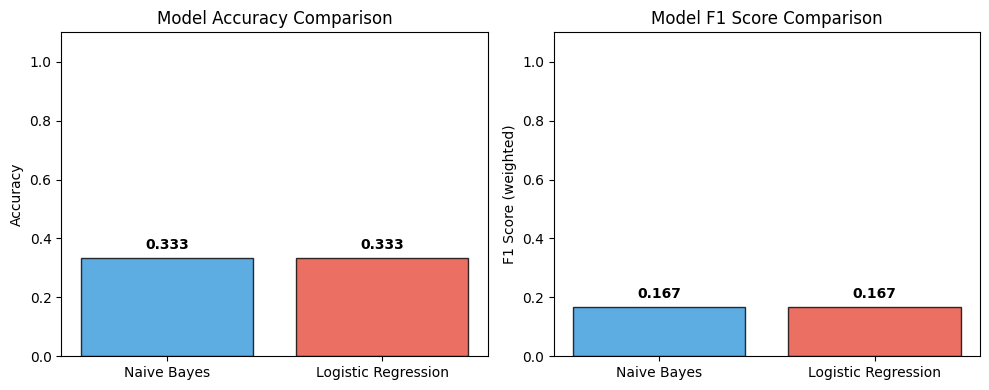

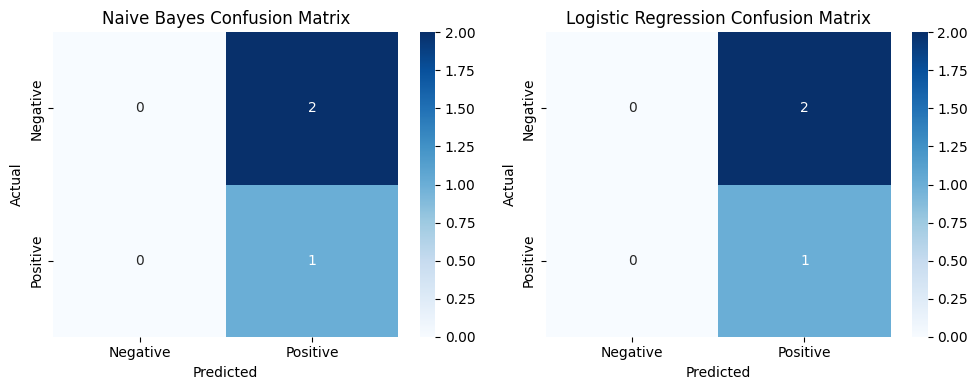

08:20:14|INFO   |Results saved to baseline_results_demo.json


In [11]:
# Collect results
results = {
    "naive_bayes": {
        "accuracy": round(nb_acc, 4),
        "f1_weighted": round(nb_f1, 4),
        "training_time_s": round(nb_time, 2),
        "report": classification_report(labels_test, nb_pred, output_dict=True),
    },
    "logistic_regression": {
        "accuracy": round(lr_acc, 4),
        "f1_weighted": round(lr_f1, 4),
        "training_time_s": round(lr_time, 2),
        "report": classification_report(labels_test, lr_pred, output_dict=True),
    },
}

# Print summary table
print("=" * 60)
print("BASELINE COMPARISON RESULTS")
print("=" * 60)
print(f"{"Model":<25} {"Accuracy":>10} {"F1 (weighted)":>15} {"Time (s)":>10}")
print("-" * 60)
print(f"{"Naive Bayes":<25} {nb_acc:>10.4f} {nb_f1:>15.4f} {nb_time:>10.2f}")
print(f"{"Logistic Regression":<25} {lr_acc:>10.4f} {lr_f1:>15.4f} {lr_time:>10.2f}")
print("-" * 60)
winner = "Logistic Regression" if lr_acc > nb_acc else "Naive Bayes"
print(f"WINNER: {winner} (acc={max(lr_acc, nb_acc):.4f})")
print("=" * 60)

# Visualization: Bar chart comparing accuracy and F1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

models = ["Naive Bayes", "Logistic Regression"]
accuracies = [nb_acc, lr_acc]
f1_scores = [nb_f1, lr_f1]
colors = ["#3498db", "#e74c3c"]

# Accuracy plot
bars1 = ax1.bar(models, accuracies, color=colors, alpha=0.8, edgecolor="black")
ax1.set_ylabel("Accuracy")
ax1.set_title("Model Accuracy Comparison")
ax1.set_ylim(0, 1.1)
for bar, acc in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{acc:.3f}", ha="center", va="bottom", fontweight="bold")

# F1 Score plot
bars2 = ax2.bar(models, f1_scores, color=colors, alpha=0.8, edgecolor="black")
ax2.set_ylabel("F1 Score (weighted)")
ax2.set_title("Model F1 Score Comparison")
ax2.set_ylim(0, 1.1)
for bar, f1 in zip(bars2, f1_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{f1:.3f}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for idx, (name, pred) in enumerate([("Naive Bayes", nb_pred), ("Logistic Regression", lr_pred)]):
    cm = confusion_matrix(labels_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES,
                ax=axes[idx])
    axes[idx].set_title(f"{name} Confusion Matrix")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Save results to JSON
out_path = Path("baseline_results_demo.json")
out_path.write_text(json.dumps(results, indent=2))
logger.info(f"Results saved to {out_path}")